In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os

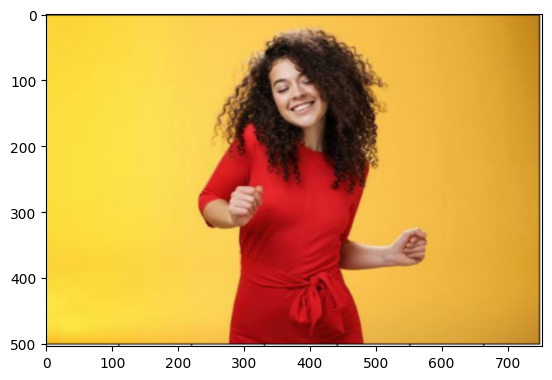

In [5]:
img = image.load_img(r'C:\Users\Yashasvi\Documents\Deep-Learning-Project\mood_classification\pictures\training\happy\happy.jpg.png')
plt.imshow(img)

In [7]:
i1  = cv2.imread(r'C:\Users\Yashasvi\Documents\Deep-Learning-Project\mood_classification\pictures\testing\h4img.png')
i1

array([[[ 70, 154, 243],
        [ 70, 154, 243],
        [ 71, 155, 244],
        ...,
        [ 46,  57,  73],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 73, 153, 244],
        [ 73, 153, 244],
        [ 73, 154, 245],
        ...,
        [ 56, 112, 187],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 74, 153, 245],
        [ 74, 153, 245],
        [ 75, 154, 245],
        ...,
        [ 60, 133, 229],
        [ 51,  84, 131],
        [ 42,  36,  34]],

       ...,

       [[ 38,  44,  62],
        [ 38,  44,  62],
        [ 38,  44,  62],
        ...,
        [ 36,  40,  52],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 38,  44,  62],
        [ 38,  44,  62],
        [ 38,  44,  62],
        ...,
        [ 41,  37,  39],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 38,  44,  62],
        [ 38,  44,  62],
        [ 38,  44,  62],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]]

In [8]:
i1.shape

(214, 340, 3)

In [9]:
train= ImageDataGenerator(rescale=1/200)
validation= ImageDataGenerator(rescale=1/200)
# to scale all the images i need to divide with 255
# we need to resize the image using 200, 200 pixel

In [10]:
train_dataset = train.flow_from_directory(r'C:\Users\Yashasvi\Documents\Deep-Learning-Project\mood_classification\pictures\training',
                                         target_size = (200,200),
                                         batch_size = 32,
                                         class_mode = 'binary')
validation_dataset = validation.flow_from_directory(r'C:\Users\Yashasvi\Documents\Deep-Learning-Project\mood_classification\pictures\validation',
                                          target_size = (200,200),
                                          batch_size = 32,
                                          class_mode = 'binary')


Found 8 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


In [11]:
train_dataset.class_indices

{'happy': 0, 'sad': 1}

In [12]:
train_dataset.classes

array([0, 0, 0, 0, 1, 1, 1, 1], dtype=int32)

In [13]:
# now we are applying maxpooling 

model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filter we applied here
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),    
                                    #                       
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2), 
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

c:\Users\Yashasvi\anaconda3\envs\newenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.001),
              metrics = ['accuracy']
              )

In [15]:
model_fit = model.fit(train_dataset,epochs=15)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.7047
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.5000 - loss: 5.0784
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5000 - loss: 2.9264
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8750 - loss: 0.5440
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6250 - loss: 0.4379
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.3524
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 1.0000 - loss: 0.2642
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 1.0000 - loss: 0.2317
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6250 - loss: 0.3795
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.2530
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8750 - loss: 0.2116
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 1.0000 - loss:

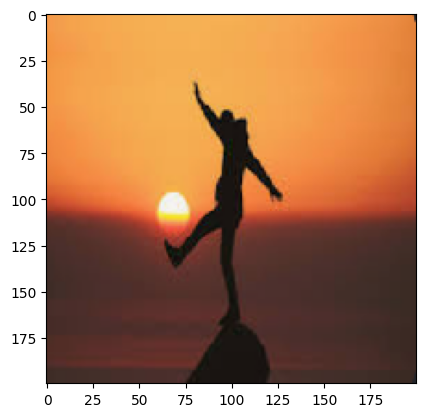

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
 i am  happy


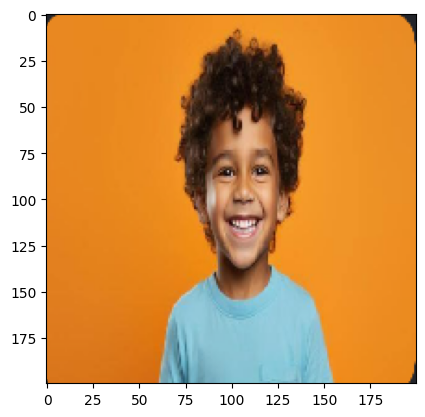

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
 i am  happy


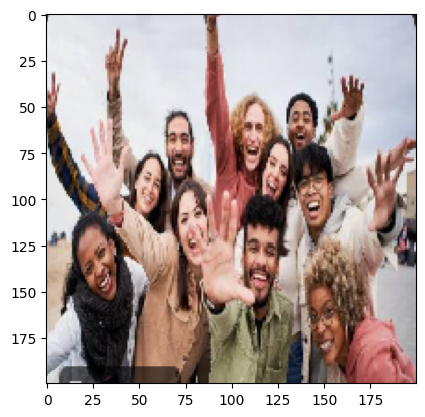

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
 i am  happy


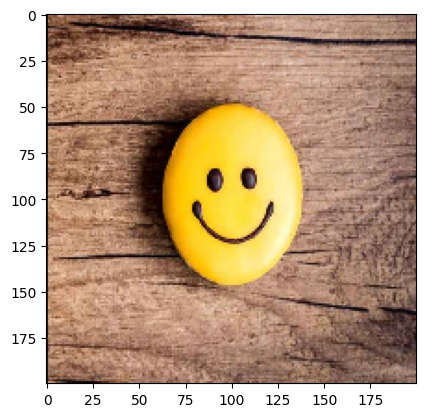

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
 i am  happy


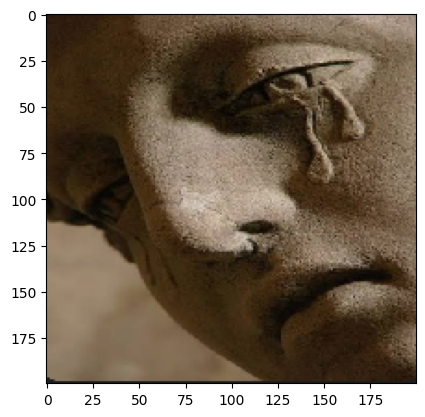

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
 i am  happy


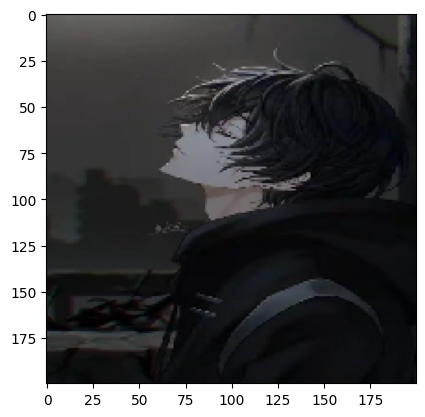

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
i am not happy


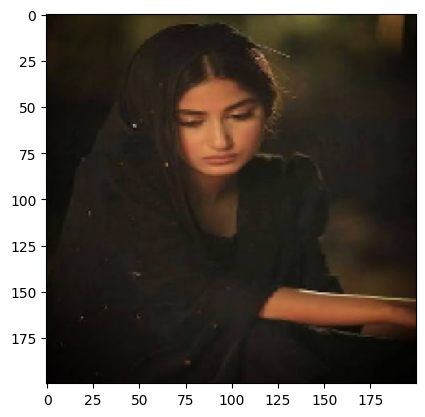

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
 i am  happy


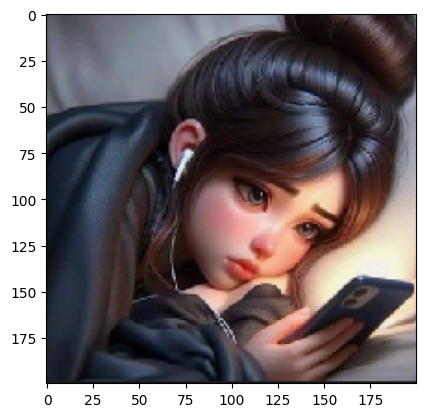

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
 i am  happy


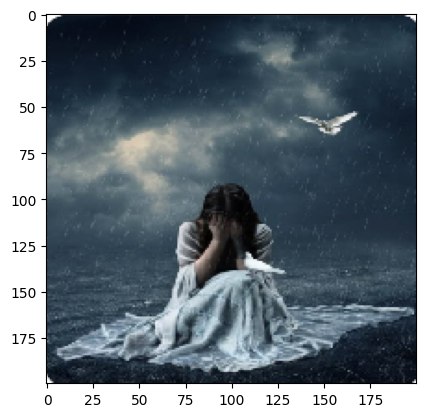

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
i am not happy


In [ ]:
dir_path = r'C:\Users\Yashasvi\Documents\Deep-Learning-Project\mood_classification\pictures\testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()
        
    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])
    
    val = model.predict(images)
    if val == 0:
        print( ' i am  happy')
    else:
        print('i am not happy') 